# Dust attenuation & the Balmer-decrement outliers

Test object **39627746074168506**-class problem on **TARGETID 39627770174637084** - the
steepest Balmer-decrement outlier in the #14 set. Its MAP fit rails at `dust1 ~ 0` and
`dust_index = +0.4`, and its observed H$\alpha$/H$\beta$ is ~22% *steeper* (more reddened)
than the model can produce.

Two questions, in order:

1. **Does the new `add_dust` port (`frac_obrun` / `frac_nodust` / `dust4`) help?**
   These let light *escape* dust, so they can only *flatten* the decrement - the wrong
   direction. We show this on the real object.
2. **What actually helps?** Freeing `dust1` from the `dust1 = dust2 * dust_ratio` coupling,
   per `dust_issue/04_proposal.md`. We show it closes the decrement at a `dust1` the coupling
   forbids, and at small continuum cost.

Everything is measured off the saved MAP fit and reproduced by re-prediction.

In [1]:
import os
os.environ["SPS_HOME"] = "/Users/ng27753/Astronomy_Research/fsps"  # FSPS data tree (dust/, data/)

import copy
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt

from hubersed.fitting.config import build_continuum_model, build_full_cue_model
from hubersed.prospector.parameter_file import build_cue_sps, build_obs
from hubersed.prospector.lsf import C_KMS, desi_resolution
from hubersed.plotting.style import use_apj_style
from prospect.sources import SSPBasis
from prospect.models.priors import TopHat
from prospect.models.sedmodel import HyperSpecModel

use_apj_style()
RESULTS = "/Users/ng27753/Astronomy_Research/hubersed/results/map_fits_outliers310_v2"
TID = 39627770174637084

/Users/ng27753/Astronomy_Research/hubersed/.venv/lib/python3.13/site-packages/prospect/sources/fake_fsps.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## 1. Load the object and reproduce its MAP fit

Build the Cue model + emulator SPS and confirm re-prediction matches the saved MAP spectrum -
this validates the whole forward-model chain before we perturb anything.

In [2]:
d = pickle.load(open(f"{RESULTS}/{TID}.pkl", "rb"))
z = float(d["z"]); theta = np.asarray(d["theta"], float); labels = list(d["labels"])
tdict = d["theta_dict"]
wave = np.asarray(d["wave"]); flux = np.asarray(d["flux"]); unc = np.asarray(d["unc"])
mask = np.asarray(d["mask"]); map_model = np.asarray(d["model"])

# DESI LSF (km/s sigma) - same recipe the fit used (pkl stores only the label string)
lsf = (C_KMS / (2.355 * desi_resolution(wave))).astype(np.float64)
obs = build_obs(spec=flux, unc=unc, mask=mask, resolution=lsf, wavelength=wave)

# Cue model: dust1 = dust2 * dust_ratio (coupled, derived), emulator nebular lines
cont_model, cont_tmpl = build_continuum_model(z)
model, tmpl = build_full_cue_model(cont_tmpl, cont_model.theta, cont_model, z)
sps = build_cue_sps()
# build_sps() applies this in the continuum stage; the Cue-only path needs it too, so
# prospect smooths with the DESI LSF alone (the saved MAP fit ran with this patch).
SSPBasis.spectral_resolution = property(lambda self: np.zeros_like(self.ssp.wavelengths))

assert model.theta_labels() == labels, "model params drifted from the saved fit"
pred, _ = model.predict(theta, observations=obs, sps=sps)
reldiff = np.nanmax(np.abs(pred[0][mask] - map_model[mask]) / np.abs(map_model[mask]))
print(f"re-predict reproduces saved MAP model: max rel diff = {reldiff:.2e}")
print("MAP dust:  dust2=%.4f   dust_ratio=%.2g (-> dust1 ~ 0)   dust_index=%.3f (rail +0.4)"
      % (theta[labels.index('dust2')], theta[labels.index('dust_ratio')],
         theta[labels.index('dust_index')]))

Loading calibrated DESI resolution from resolution matrices...


re-predict reproduces saved MAP model: max rel diff = 2.54e-05
MAP dust:  dust2=0.1619   dust_ratio=1.5e-11 (-> dust1 ~ 0)   dust_index=0.400 (rail +0.4)


## 2. Baseline decrement

The model H$\alpha$/H$\beta$ comes straight from the dust-attenuated Cue line luminosities
(`model._eline_lum`). The observed decrement is implied from the recorded per-line data/model
ratios: `observed = model x (data/model)_Ha / (data/model)_Hb`.

In [3]:
HA, HB = 6564.6, 4862.7   # rest-frame, Angstrom

def balmer(mdl, th, **params):
    "Model Halpha/Hbeta from attenuated Cue lines; returns (ratio, model_spectrum)."
    mdl.params["frac_obrun"]  = params.get("frac_obrun", 0.0)
    mdl.params["frac_nodust"] = params.get("frac_nodust", 0.0)
    mdl.params["dust4_type"]  = params.get("dust4_type", 0)
    mdl.params["dust4_index"] = params.get("dust4_index", 0.0)
    mdl.params["dust4"]       = params.get("dust4", 0.0)
    pr, _ = mdl.predict(th, observations=obs, sps=sps)
    ew = np.asarray(mdl._eline_wave); el = np.asarray(mdl._eline_lum)
    iHa = int(np.argmin(np.abs(ew - HA))); iHb = int(np.argmin(np.abs(ew - HB)))
    return el[iHa] / el[iHb], np.asarray(pr[0])

D_map, _ = balmer(model, theta)
ratio_of_ratios = d["line_ratios"]["Ha"] / d["line_ratios"]["Hb"]
D_obs = D_map * ratio_of_ratios
print(f"model  Ha/Hb (MAP)          = {D_map:.3f}")
print(f"data/model ratio-of-ratios  = {ratio_of_ratios:.3f}")
print(f"observed Ha/Hb (implied)    = {D_obs:.3f}   -> model is {100*(D_obs/D_map-1):.0f}% too shallow")

model  Ha/Hb (MAP)          = 2.931
data/model ratio-of-ratios  = 1.216
observed Ha/Hb (implied)    = 3.565   -> model is 22% too shallow


## 3. Step 1 - the port moves the wrong way

`frac_obrun` lets the young component escape the birth cloud (`dust1`). At the MAP `dust1 ~ 0`
so it is **inert**; force `dust1` up and it **flattens** the decrement - away from observed.

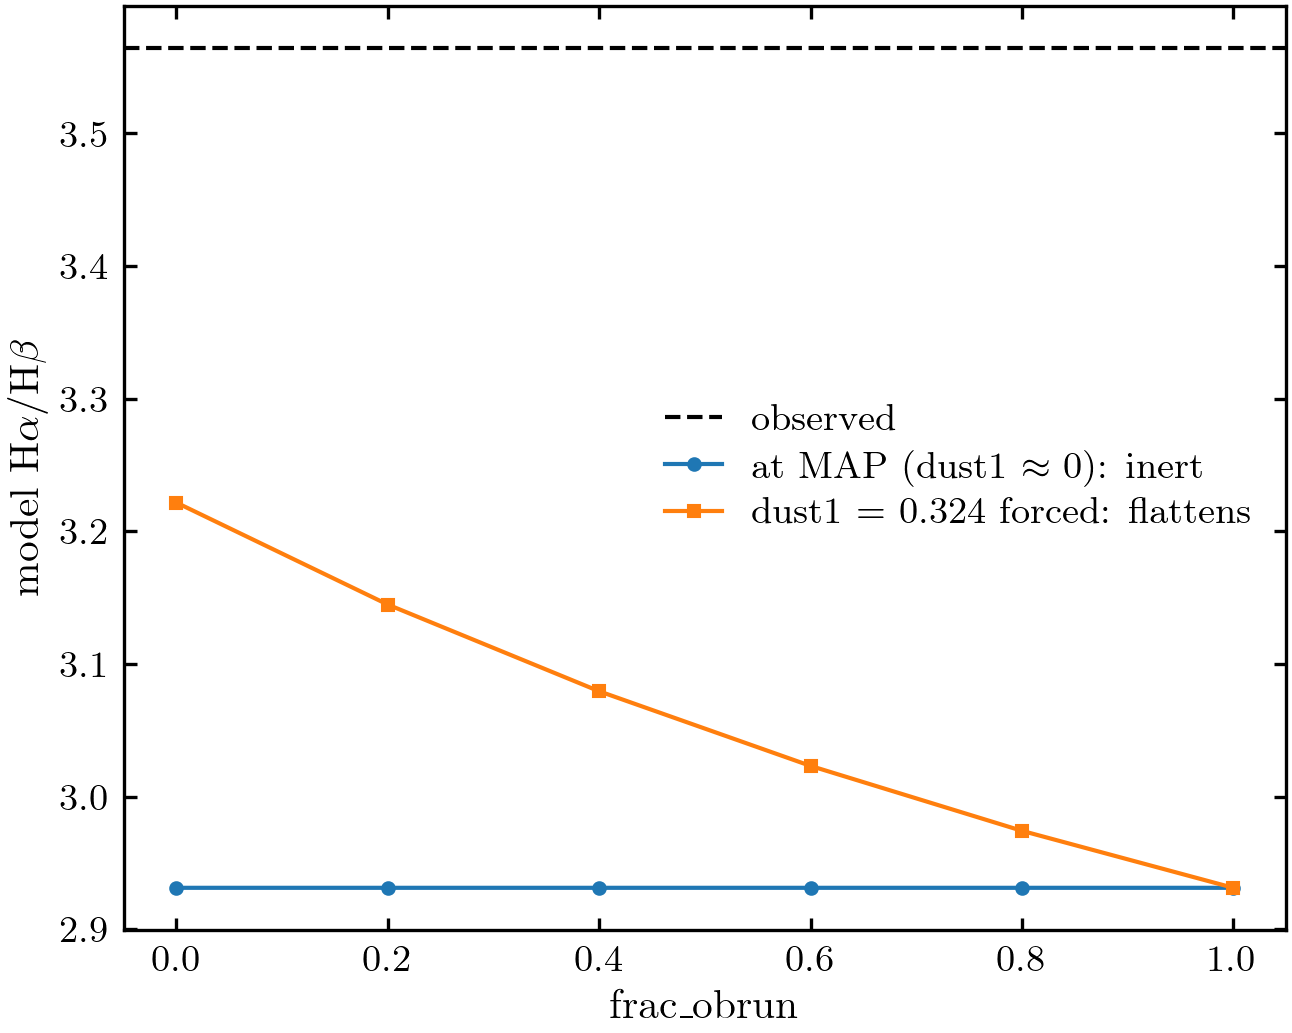

In [4]:
fracs = np.linspace(0, 1, 6)
D_a = [balmer(model, theta, frac_obrun=f)[0] for f in fracs]              # dust1 ~ 0 (MAP)
theta_d1 = theta.copy(); theta_d1[labels.index("dust_ratio")] = 2.0        # dust1 = dust2*2 = 0.324
D_b = [balmer(model, theta_d1, frac_obrun=f)[0] for f in fracs]

fig, ax = plt.subplots(figsize=(5, 4))
ax.axhline(D_obs, color="k", ls="--", lw=1, label="observed")
ax.plot(fracs, D_a, "o-", label=r"at MAP (dust1 $\approx$ 0): inert")
ax.plot(fracs, D_b, "s-", label="dust1 = 0.324 forced: flattens")
ax.set_xlabel("frac_obrun"); ax.set_ylabel(r"model H$\alpha$/H$\beta$")
ax.legend(frameon=False); plt.show()

`dust4` (AGN power-law, negative index) *can* steepen the decrement - but raising the
ordinary diffuse `dust2` does the same thing. `dust4` is just another diffuse screen,
degenerate with `dust2`, not a new capability for this problem.

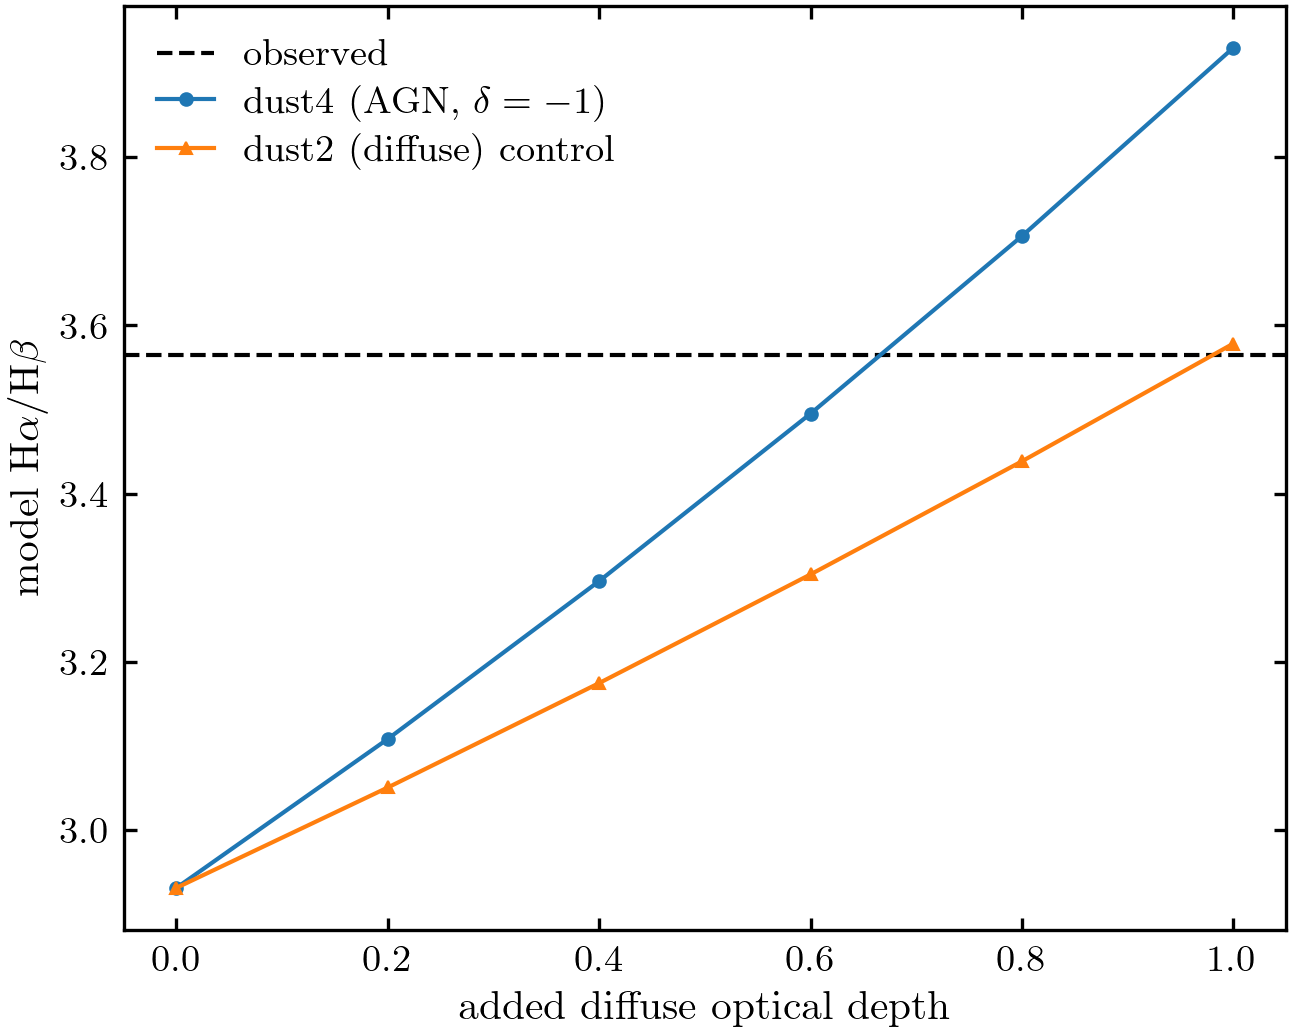

In [5]:
added = np.linspace(0, 1.0, 6)
D_d4 = [balmer(model, theta, dust4_type=1, dust4_index=-1.0, dust4=x)[0] for x in added]
d2_0 = theta[labels.index('dust2')]
D_d2 = []
for x in added:
    th = theta.copy(); th[labels.index('dust2')] = d2_0 + x
    D_d2.append(balmer(model, th)[0])

fig, ax = plt.subplots(figsize=(5, 4))
ax.axhline(D_obs, color="k", ls="--", lw=1, label="observed")
ax.plot(added, D_d4, "o-", label=r"dust4 (AGN, $\delta=-1$)")
ax.plot(added, D_d2, "^-", label="dust2 (diffuse) control")
ax.set_xlabel("added diffuse optical depth"); ax.set_ylabel(r"model H$\alpha$/H$\beta$")
ax.legend(frameon=False); plt.show()

## 4. Step 2 - freeing dust1 is the fix

`dust2` *could* reach the observed decrement, but it reddens the whole continuum, which is why
the fit pins it at 0.162. `dust1` reddens the young component only (~99% of the line flux),
so it can steepen the decrement with little continuum cost - but the coupling caps it at
`dust2 x 2 = 0.324`. Free it and sweep.

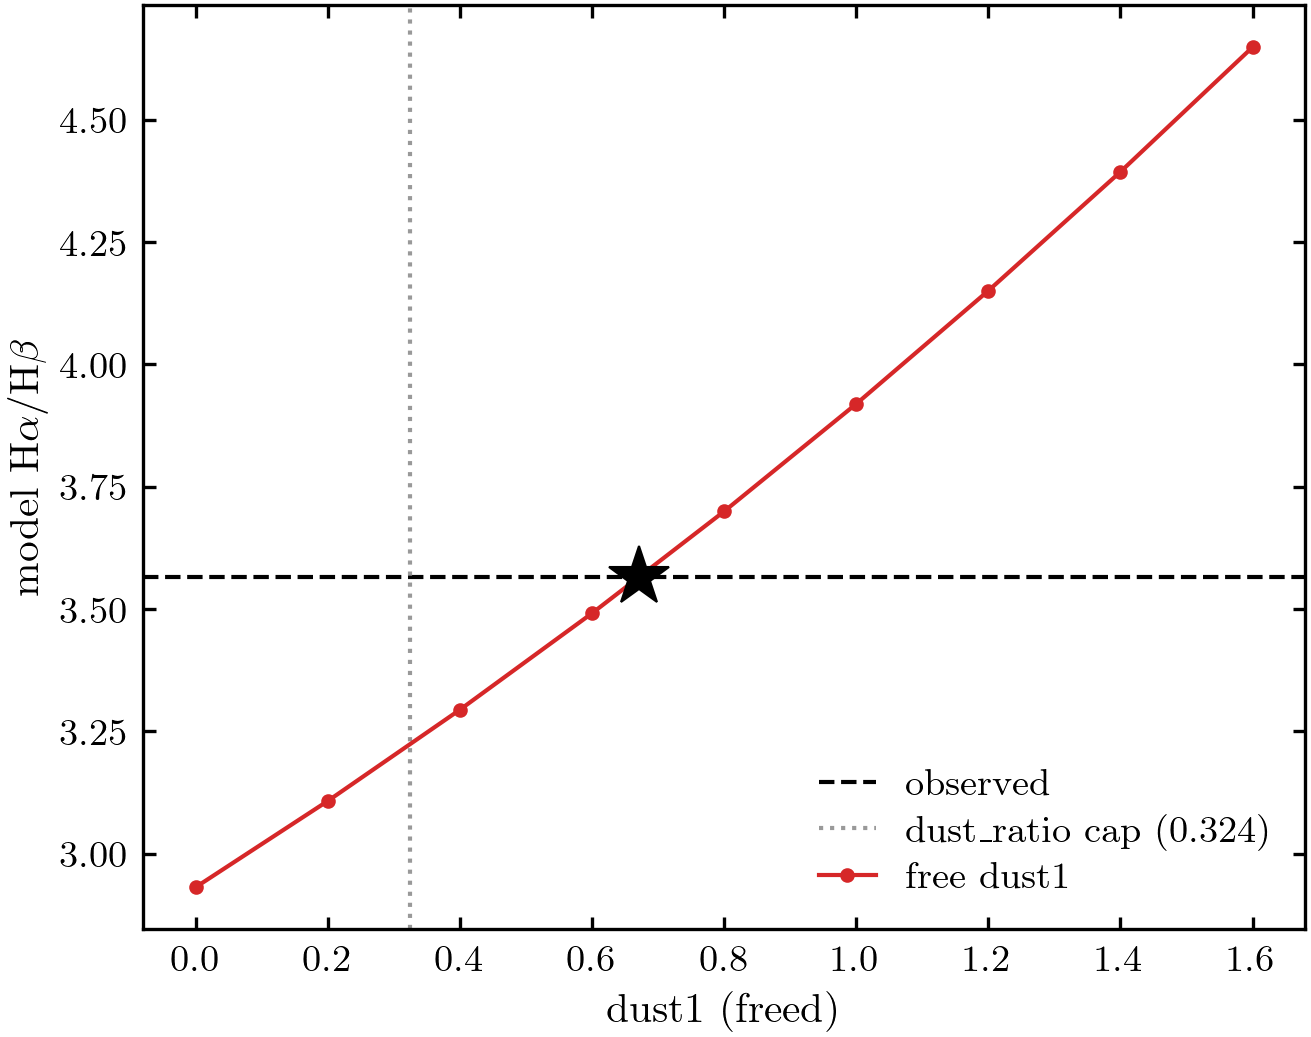

dust1 that closes the decrement: 0.67   (coupling caps it at 0.324)


In [6]:
tmpl2 = copy.deepcopy(tmpl)                 # isolate from the coupled `model`
tmpl2["dust1"] = {"N": 1, "isfree": True, "init": 0.0,
                  "units": "birth-cloud optical depth", "prior": TopHat(mini=0.0, maxi=3.0)}
tmpl2["dust_ratio"]["isfree"] = False             # retire the coupling
model2 = HyperSpecModel(tmpl2)

th0 = model2.theta.copy()                          # seed freed model from the MAP values
for name in model2.free_params:
    if name in tdict:
        th0[model2.theta_index[name]] = np.atleast_1d(tdict[name])

d1_grid = np.linspace(0, 1.6, 9)
D_d1 = []
for dd in d1_grid:
    th = th0.copy(); th[model2.theta_index["dust1"]] = dd
    D_d1.append(balmer(model2, th)[0])
D_d1 = np.array(D_d1)
d1_close = float(np.interp(D_obs, D_d1, d1_grid))

fig, ax = plt.subplots(figsize=(5, 4))
ax.axhline(D_obs, color="k", ls="--", lw=1, label="observed")
ax.axvline(0.324, color="0.6", ls=":", lw=1, label="dust_ratio cap (0.324)")
ax.plot(d1_grid, D_d1, "o-", color="C3", label="free dust1")
ax.plot(d1_close, D_obs, "*", ms=15, color="k")
ax.set_xlabel("dust1 (freed)"); ax.set_ylabel(r"model H$\alpha$/H$\beta$")
ax.legend(frameon=False); plt.show()
print(f"dust1 that closes the decrement: {d1_close:.2f}   (coupling caps it at 0.324)")

### Continuum cost: dust1 vs dust2 to the same decrement

Match the observed decrement two ways - freed `dust1`, or raised diffuse `dust2` - and compare
the continua. The `dust2` route bends the whole SED; the `dust1` route barely moves it.

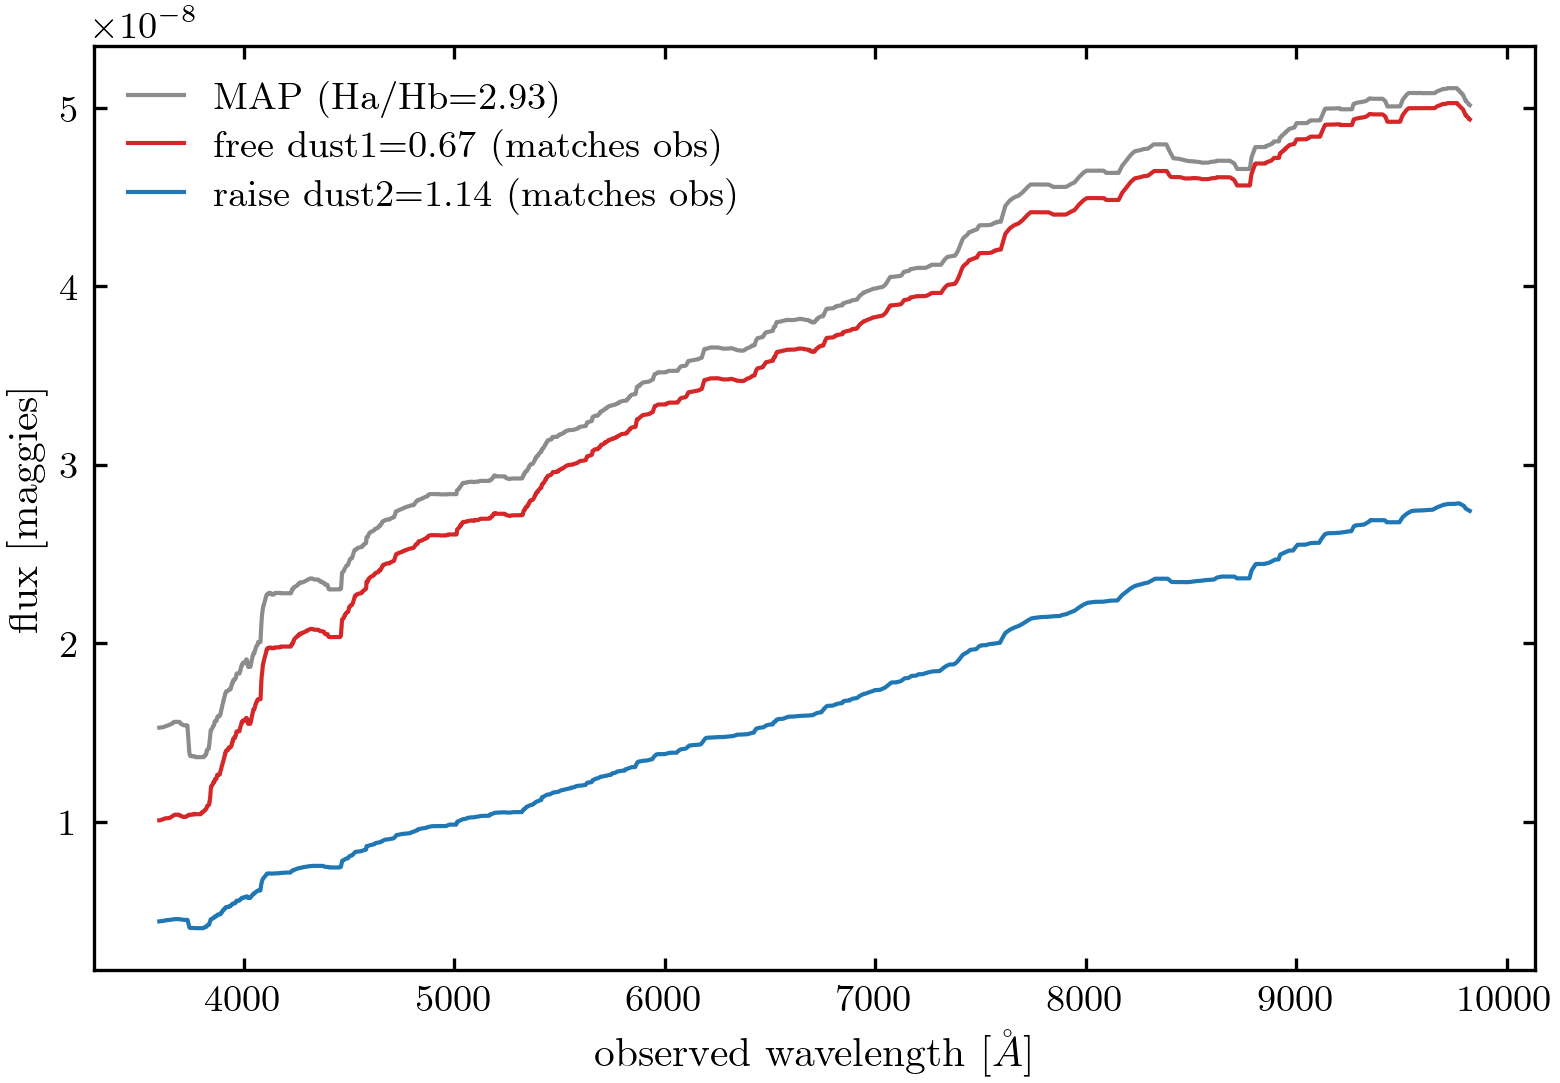

continuum median |frac change| vs MAP:  dust1 route = 0.053   dust2 route = 0.608


In [7]:
# dust2 (with dust1=0) needed to hit the same decrement
d2_grid = np.linspace(d2_0, 2.0, 8); D_d2f = []
for x in d2_grid:
    th = theta.copy(); th[labels.index('dust2')] = x; th[labels.index('dust_ratio')] = 0.0
    D_d2f.append(balmer(model, th)[0])
d2_close = float(np.interp(D_obs, D_d2f, d2_grid))

th_d1 = th0.copy(); th_d1[model2.theta_index["dust1"]] = d1_close
_, spec_d1 = balmer(model2, th_d1)
th_d2 = theta.copy(); th_d2[labels.index('dust2')] = d2_close; th_d2[labels.index('dust_ratio')] = 0.0
_, spec_d2 = balmer(model, th_d2)
_, spec_0  = balmer(model, theta)

mf = lambda x: medfilt(x, 151)
fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(wave, mf(spec_0),  color="0.55", label=f"MAP (Ha/Hb={D_map:.2f})")
ax.plot(wave, mf(spec_d1), color="C3",  label=f"free dust1={d1_close:.2f}  (matches obs)")
ax.plot(wave, mf(spec_d2), color="C0",  label=f"raise dust2={d2_close:.2f}  (matches obs)")
ax.set_xlabel(r"observed wavelength [$\AA$]"); ax.set_ylabel("flux [maggies]")
ax.legend(frameon=False); plt.show()

cont_cost = lambda s: float(np.nanmedian(np.abs(s - spec_0)[mask] / (np.abs(spec_0)[mask] + 1e-30)))
print(f"continuum median |frac change| vs MAP:  dust1 route = {cont_cost(spec_d1):.3f}   "
      f"dust2 route = {cont_cost(spec_d2):.3f}")

## Conclusion

- **`frac_obrun` / `frac_nodust` cannot fix these outliers**: inert at `dust1 = 0` (3 of 4 of
  the #14 set), and they *flatten* the decrement when `dust1 > 0`. Wrong direction.
- **`dust4` is degenerate** with `dust2` for this - no new capability, and it is AGN physics.
- **Freeing `dust1`** closes the decrement at `dust1 ~ 0.7`, which the `dust1 = dust2 x dust_ratio`
  coupling forbids (cap 0.324), and at a fraction of the continuum cost of the `dust2` route.

The port is correct and useful for other purposes, but the Balmer-decrement outliers want
`dust1` freed, not light let out of the dust. Next: a real re-fit (not a single-parameter sweep)
to confirm the freed `dust1` lands here and doesn't just move the rail, and the `gas_logqion`
amplitude half decided alongside it.